# What are the most demanded skills for 3 most popular data roles?
## Methodology
    1. Clean-up skill column
    2. Calculate skill count based on job_title_short
    3. Calculate skill percentage
    4. Plot final findings


In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

# Loading Data & Cleaning Up
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\data_jobs.csv')
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

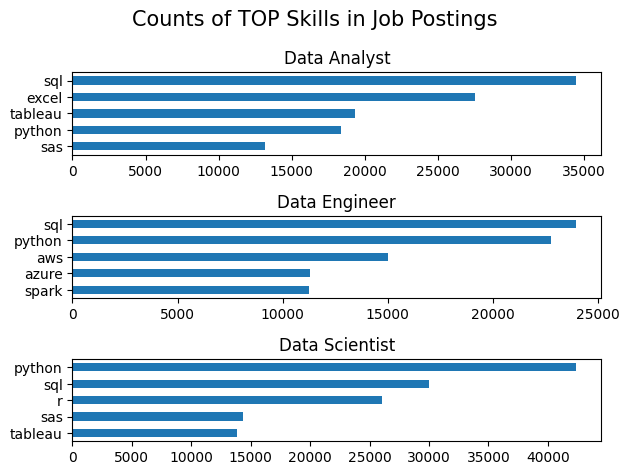

In [2]:
# Skill Demand in US
df_us= df[df['job_country'] == 'United States']
df_skills = df_us.explode('job_skills')

df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name = 'skill_count')
df_skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

job_titles = sorted(df_skills_count['job_title_short'].unique().tolist()[:3])

fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_count', ax = ax[i], title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

# Show the Counts of TOP Skills in Job Postings
fig.suptitle('Counts of TOP Skills in Job Postings', fontsize = 15)
plt.tight_layout()
plt.show()

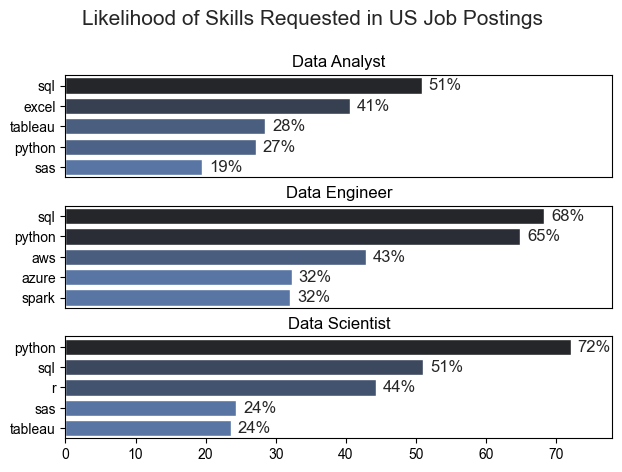

In [3]:
df_job_title_count = df_us['job_title_short'].value_counts().reset_index(name = 'jobs_total')
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, how = 'left', on = 'job_title_short')
df_skill_perc['skill_percent'] = 100 * df_skill_perc['skill_count'] / df_skill_perc['jobs_total']

fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style = 'darkgrid')

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data = df_plot, x = 'skill_percent', y = 'job_skills', ax = ax[i], hue = 'skill_count', palette = 'dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 78)
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va = 'center')
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize = 15)
fig.tight_layout(h_pad = 0.5)
plt.show()